# Evolution Plots (Tao et al. 2026)

This notebook contains the scripts to re-create the plots of Tao et al. 2026 (in prep). Comments and more detail for this tutorial are to come.

Send any questions to extao@ucsc.edu!

## I. Setup

In [1]:
#Modules
import sys, os
sys.path.insert(0, './Models')
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from scipy.interpolate import RegularGridInterpolator
import pandas as pd

### Preparing composition curves
Code taken from Artem Aguichine's [MARDIGRAS](https://github.com/an0wen/MARDIGRAS)

In [2]:
#constants and astronomical units
M_e   = 5.972e24  #Earth mass (kg)
R_e   = 6.371e6   #Earth radius (m)

M_sun = 1.988e30  #Solar mass (kg)
R_sun = 6.955e10  #Solar radius (m)
L_sun = 3.828e26  #luminosity of the Sun (Watts, kg⋅m^2⋅s^-3)
T_sun = 5778      #Solar temperature (K)

au    = 1.496e11  #astronomical unit (m)
Gyr   = 3.153e16  #seconds in 1 billion years
G     = 6.674e-11 #gravitational constant (m^3⋅kg^-1⋅s^-2)

In [ ]:
#MARDIGRAS stuff

xmin, xmax, nx = 0.1, 20-1e-5, 50 # 0.5, 20
ymin, ymax  = .75, 4.25

path_models='./Models/'
x = np.logspace(np.log10(xmin), np.log10(xmax), nx)

#MARDIGRAS stuff

xmin, xmax, nx = 0.1, 19.99999, 50 # 0.5, 20
ymin, ymax  = .75, 4.25

##############################################
#
#   MAKE SWEET INTERPOLATOR (Aguichine+2025)
#
##############################################

path_sweet = path_models + "Aguichine2025_SWEET_all.dat"

# top of the atmosphere pressure (index)
sweet_top = np.array([0,1])
sweet_labels_top = ["20 mbar", "1 µbar"]
# host star type
sweet_labels_host = ["Type M", "Type G"]
# equilibrium temperature at zero albedo (K)
sweet_teqs = np.array([400, 500, 700, 900, 1100, 1300, 1500])
# bulk water mass fraction (%)
sweet_wmfs = np.array([0.1,1,10,20,30,40,50,60,70,80,90,100])
# total planet mass (Me)
sweet_masses = np.array([0.2       ,  0.254855  ,  0.32475535,  0.41382762,  0.52733018,
        0.67196366,  0.85626648,  1.09111896,  1.39038559,  1.77173358,
        2.25767578,  2.87689978,  3.66596142,  4.67144294,  5.95270288,
        7.58538038,  9.66586048, 12.31696422, 15.69519941, 20.        ])
# planet age (Gyr)
sweet_ages = np.array([0.001,0.0015,0.002,0.003,0.005,0.01,
                        0.02,0.03,0.05,
                        0.1,0.2,0.5,
                        1.0,2.0,5.0,
                        10,20])

# make dimension axes for interpolator
sweet_dim_wmf = sweet_wmfs.copy()/100
sweet_dim_teq = sweet_teqs.copy()
sweet_dim_mass = sweet_masses.copy()
sweet_dim_age = sweet_ages.copy()
sweet_dim_star = np.array([0,1])
sweet_dim_top = np.array([0,1])

# read radius tracks data and reshape
listrpfull1 = np.loadtxt(path_sweet,skiprows=36,unpack=True,usecols=(6))
listrpfull2 = np.loadtxt(path_sweet,skiprows=36,unpack=True,usecols=(7))
listrpfull = np.array((listrpfull1,listrpfull2))
listrpfull = np.delete(listrpfull, np.arange(17, listrpfull.size, 18))

sweet_data_radius = np.reshape(listrpfull,(2,2,12,7,20,17))
mask = np.isnan(sweet_data_radius)
sweet_data_radius[mask] = -1

# fill_value: value to return when extrapolating beyond grid validity range
fill_value = None
interp_sweet = RegularGridInterpolator((sweet_dim_top,
                                      sweet_dim_star,
                                      sweet_dim_wmf,
                                      sweet_dim_teq,
                                      sweet_dim_mass,
                                      sweet_dim_age), 
                                     sweet_data_radius, method='slinear', bounds_error=False, fill_value=fill_value)


# The parametrized function to be plotted
def radius_m(x,wmf_swe,teq_swe,age_swe):
    input0 = np.stack([np.full(len(x),0), np.full(len(x),0), np.full(len(x),wmf_swe), np.full(len(x),teq_swe), x, np.full(len(x),age_swe)],axis=-1)
    # input0 = np.stack(0, 0, (np.full(len(x),wmf_swe),np.full(len(x),teq_swe),x,np.full(len(x),age_swe)), axis=-1)
    return interp_sweet(input0)

def radius_g(x,wmf_swe,teq_swe,age_swe):
    input0 = np.stack([np.full(len(x),0), np.full(len(x),1), np.full(len(x),wmf_swe), np.full(len(x),teq_swe), x, np.full(len(x),age_swe)],axis=-1)
    # input0 = np.stack(0, 1, (np.full(len(x),wmf_swe),np.full(len(x),teq_swe),x,np.full(len(x),age_swe)), axis=-1)
    return interp_sweet(input0)


# Define initial parameters
init_host_swe = 0
init_wmf_swe = 0.5
init_teq_swe = 600.0
init_age_swe = 1.0

init_wmf_swe100 = 1.0

# line_swe_g, = plt.plot(
#     x, radius_g(x,init_wmf_swe,init_teq_swe,init_age_swe),lw=0.75,color='teal',linestyle='-.',zorder=-100)#,label='50% Steam')

# line_swe_g100, = plt.plot(
#     x, radius_g(x,init_wmf_swe100,init_teq_swe,init_age_swe),lw=0.75,color='teal',zorder=-100)#,label='100% Steam')

#swe stuff
swe_func = [radius_m, radius_g]
swe_labels = ["Type M", "Type G"]  # Optional labels for each 

##############################################
# Load Zeng data
# path_zeng = path_models + "Zeng2016.dat"

# # Load curves from Zeng et al. 2016
# zeng_mass,zeng_purefe,zeng_rock,zeng_50wat,zeng_100wat,zeng_earth = np.loadtxt(path_zeng,delimiter="\t",skiprows=1,unpack=True)

# open files
list_zeng_fe_m,list_zeng_fe_r = np.loadtxt(path_models+"zeng2016-iron.dat",unpack=True,usecols=(0,1))
list_zeng_ea_m,list_zeng_ea_r = np.loadtxt(path_models+"zeng2016-earth.dat",unpack=True,usecols=(0,1))
list_zeng_mg_m,list_zeng_mg_r = np.loadtxt(path_models+"zeng2016-rock.dat",unpack=True,usecols=(0,1))

list_zeng_masses = np.logspace(np.log10(0.01), np.log10(100.0), 30)

# reshape radius data to the same vector
list_zeng_fe_radii = np.interp(list_zeng_masses, list_zeng_fe_m, list_zeng_fe_r)
list_zeng_ea_radii = np.interp(list_zeng_masses, list_zeng_ea_m, list_zeng_ea_r)
list_zeng_mg_radii = np.interp(list_zeng_masses, list_zeng_mg_m, list_zeng_mg_r)

# create interpolator
dimcmf_zeng = np.array([0.0,0.325,1.0])
data_zeng = np.vstack((list_zeng_mg_radii, list_zeng_ea_radii,list_zeng_fe_radii)).T
interp_zeng = RegularGridInterpolator((list_zeng_masses,dimcmf_zeng), data_zeng, method='linear', bounds_error=False, fill_value=None)

# parameterized func to plot
def rad_zeng(x,cmf):
    input0 = np.stack((x,np.full(len(x),cmf)), axis=-1)
    rp = interp_zeng(input0)
    return rp

init_cmf_zeng = 0.325

# Zeng fixed
zeng_width = 1.0

## II. Evolution Trails _(Fig 2)_

This plot illustrates the evolution curves of the same population using H-He and H2O escape rates with the plots stacked.

### Import data

In [4]:
#We want datasets for BOTH H2O and H-He
n_planets = 5000

#masses
H2O_init_mp = np.array([])
HHe_init_mp = np.array([])
H2O_fin_mp = np.array([])
HHe_fin_mp = np.array([])

#radii
H2O_init_rp = np.array([])
HHe_init_rp = np.array([])
H2O_fin_rp = np.array([])
HHe_fin_rp = np.array([])

identifier = f'{n_planets}_xp'
filepath = "paper/"+identifier
savepath = "paper/plots" #where we're saving our plots

population_file = filepath + '/5000_xp_gp_data.csv'
planetnum, mp_gp, rp_gp, period_gp = np.loadtxt(population_file, usecols=(0,1,2,11), skiprows=1,unpack=True)

#### Customize
If you want to change from the default colors.

In [5]:
#DATA
planets_plotted = 200 #DEFAULT: 200

#COSMETIC
init_color = '' #DEFAULT: 
fin_color = '' #DEFAULT: 
trail_color = '' #DEFAULT: 

Planet 6 evolution failed. 9.476, 2.592
 [-2]	paper/5000_xp/H-He/planet_50-5000_evolution_data.csv
 [-2]	paper/5000_xp/H-He/planet_52-5000_evolution_data.csv
 [-2]	paper/5000_xp/H-He/planet_58-5000_evolution_data.csv
 [-2]	paper/5000_xp/H-He/planet_64-5000_evolution_data.csv
 [-2]	paper/5000_xp/H-He/planet_81-5000_evolution_data.csv


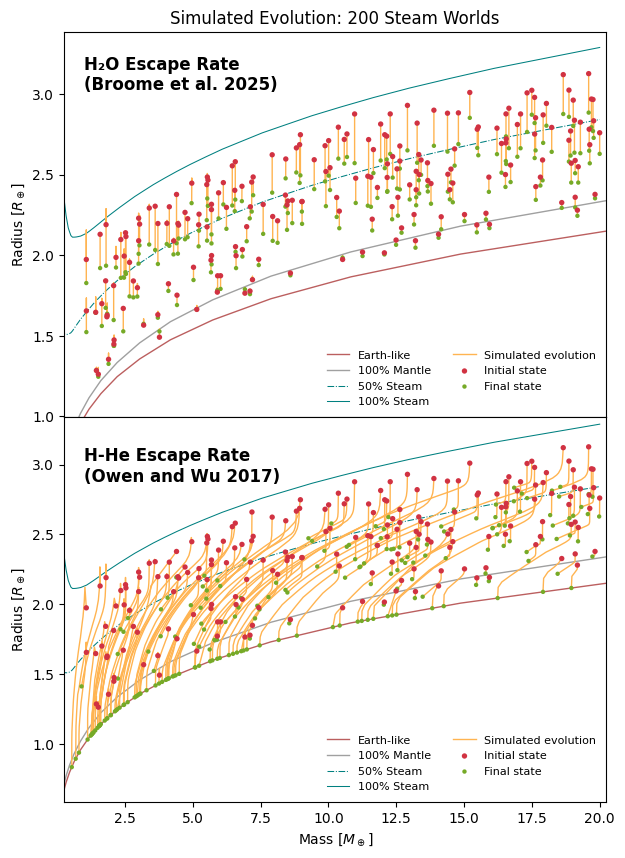

In [ ]:
# Set up plot
fig, ax = plt.subplots(2,1, figsize=(7,10))#, sharex=True)
fig.subplots_adjust(hspace=0) 

FAIL = 0 #number that have less than 3 data points; this indicates a failed evolution. Only occurs with H-He planets

mdot_text = 'M' + '\u0307'
ax[0].text(1,3, f'H\u2082O Escape Rate \n(Broome et al. 2025)', fontsize='large', weight='semibold',ha='left', va='bottom')
ax[0].plot(list_zeng_masses,list_zeng_ea_radii,linewidth=zeng_width,color='brown',alpha=0.75,zorder=-100,label='Earth-like') # Earthlike
ax[0].plot(list_zeng_masses,list_zeng_mg_radii,linewidth=zeng_width,color='grey',alpha=0.75,zorder=-100, label='100% Mantle')  # 100% Mantle
ax[0].plot(x, radius_m(x,init_wmf_swe,init_teq_swe,init_age_swe),lw=0.75,color='teal',linestyle='-.',zorder=-200,label='50% Steam')
ax[0].plot(x, radius_g(x,init_wmf_swe100,init_teq_swe,init_age_swe),lw=0.75,color='teal',zorder=-200,label='100% Steam')

ax[1].text(1,2.85, 'H-He Escape Rate \n(Owen and Wu 2017)', fontsize='large', weight='semibold',ha='left', va='bottom')
ax[1].plot(list_zeng_masses,list_zeng_ea_radii,linewidth=zeng_width,color='brown',alpha=0.75,zorder=-100,label='Earth-like') # Earthlike
ax[1].plot(list_zeng_masses,list_zeng_mg_radii,linewidth=zeng_width,color='grey',alpha=0.75,zorder=-100, label='100% Mantle')  # 100% Mantle
ax[1].plot(x, radius_m(x,init_wmf_swe,init_teq_swe,init_age_swe),lw=0.75,color='teal',linestyle='-.',zorder=-200,label='50% Steam')
ax[1].plot(x, radius_g(x,init_wmf_swe100,init_teq_swe,init_age_swe),lw=0.75,color='teal',zorder=-200,label='100% Steam')

#Plot each trail individually. Takes ~10s
for i in range (planets_plotted):
    planetnum = i+1

    if i==0:
        label="Simulated evolution"
    else:
        label=None

    H2O_data = f'{filepath}/H2O/planet_{planetnum}-{n_planets}_evolution_data.csv' #imported in Earth units
    H2O_time_arr, H2O_mp_arr, H2O_rp_arr, H2O_wmf_arr, H2O_mdot_arr = np.loadtxt(H2O_data,usecols=(0,1,2,3,4),unpack=True) #,skiprows=1

    HHe_data = f'{filepath}/H-He/planet_{planetnum}-{n_planets}_evolution_data.csv' #imported in Earth units
    HHe_time_arr, HHe_mp_arr, HHe_rp_arr, HHe_wmf_arr, HHe_mdot_arr = np.loadtxt(HHe_data,unpack=True) #,skiprows=1

    H2O_init_mp = np.append(H2O_init_mp, H2O_mp_arr[0])
    H2O_init_rp = np.append(H2O_init_rp, H2O_rp_arr[0])

    H2O_fin_mp = np.append(H2O_fin_mp, H2O_mp_arr[-1])
    H2O_fin_rp = np.append(H2O_fin_rp, H2O_rp_arr[-1])

    if np.isnan(HHe_mp_arr[-1]) or np.isnan(HHe_rp_arr[-1]):
        if len(HHe_mp_arr) <3:
            print(f"Planet {planetnum} evolution failed. {HHe_mp_arr[0]/M_e:.3f}, {HHe_rp_arr[0]/R_e:.3f}")
            FAIL += 1
        else:
            print(f"Warning: NaN detected in H-He data for planet {planetnum}.\n [-2]\t{HHe_data}")#,HHe_mp_arr[-2]/M_e,HHe_rp_arr[-2]/R_e)
            HHe_init_mp = np.append(HHe_init_mp, HHe_mp_arr[0])
            HHe_init_rp = np.append(HHe_init_rp, HHe_rp_arr[0])

            HHe_fin_mp = np.append(HHe_fin_mp, HHe_mp_arr[-2])
            HHe_fin_rp = np.append(HHe_fin_rp, HHe_rp_arr[-2])
    else:
        HHe_init_mp = np.append(HHe_init_mp, HHe_mp_arr[0])
        HHe_init_rp = np.append(HHe_init_rp, HHe_rp_arr[0])
        HHe_fin_mp = np.append(HHe_fin_mp, HHe_mp_arr[-1]) #[-2] to evade nan issues
        HHe_fin_rp = np.append(HHe_fin_rp, HHe_rp_arr[-1])
        # print(HHe_mp_arr[-1],HHe_rp_arr[-1])
    
    #plot
    # ax[0].plot(H2O_mp_arr[0]/M_e, H2O_rp_arr[0]/R_e,  c='#D13242', alpha=1, markersize=200, markeredgecolor='none', zorder=50)
    # ax[0].plot(H2O_mp_arr[-1]/M_e, H2O_rp_arr[-1]/R_e,  c='#76AA27', alpha=1, markersize=15,markeredgecolor='none', zorder=50)

    # ax[1].plot(HHe_mp_arr[0]/M_e, HHe_rp_arr[0]/R_e,  c='#D13242', alpha=1, markersize=200, markeredgecolor='none', zorder=50)
    # ax[1].plot(HHe_mp_arr[-1]/M_e, HHe_rp_arr[-1]/R_e,  c='#76AA27', alpha=1, markersize=15, markeredgecolor='none', zorder=50)

    ax[0].plot(H2O_mp_arr/M_e, H2O_rp_arr/R_e, c="#FFB451", label=label, linewidth=1)
    ax[1].plot(HHe_mp_arr/M_e, HHe_rp_arr/R_e, c='#FFB451', label=label, linewidth=1)

#doesn't include a double failsafe, will be a future feature
for i in range(FAIL):
    planetnum += 1
    HHe_data = f'{filepath}/H-He/planet_{planetnum}-{n_planets}_evolution_data.csv' #imported in Earth units
    HHe_time_arr, HHe_mp_arr, HHe_rp_arr, HHe_wmf_arr, HHe_mdot_arr = np.loadtxt(HHe_data,unpack=True) #,skiprows=1

    if np.isnan(HHe_mp_arr[-1]) or np.isnan(HHe_rp_arr[-1]):
        if len(HHe_mp_arr) <3:
            print(f"Planet {planetnum} evolution failed. ({HHe_mp_arr[0]/M_e:.3f}, {HHe_rp_arr[0]/R_e:.3f})")
            FAIL += 1
        else:
            print(f"Warning: NaN detected in H-He data for planet {planetnum}.\n [-2]\t{HHe_data}")
            HHe_init_mp = np.append(HHe_init_mp, HHe_mp_arr[0])
            HHe_init_rp = np.append(HHe_init_rp, HHe_rp_arr[0])

            HHe_fin_mp = np.append(HHe_fin_mp, HHe_mp_arr[-2])
            HHe_fin_rp = np.append(HHe_fin_rp, HHe_rp_arr[-2])
    else:
        HHe_init_mp = np.append(HHe_init_mp, HHe_mp_arr[0])
        HHe_init_rp = np.append(HHe_init_rp, HHe_rp_arr[0])
        HHe_fin_mp = np.append(HHe_fin_mp, HHe_mp_arr[-1]) #[-2] to evade nan issues
        HHe_fin_rp = np.append(HHe_fin_rp, HHe_rp_arr[-1])
        # print(HHe_mp_arr[-1],HHe_rp_arr[-1])
    #plot
    # ax[0].plot(H2O_mp_arr[0]/M_e, H2O_rp_arr[0]/R_e,  c='#D13242', alpha=1, markersize=15, markeredgecolor='none', zorder=50)
    # ax[0].plot(H2O_mp_arr[-1]/M_e, H2O_rp_arr[-1]/R_e,  c='#76AA27', alpha=1, markersize=15,markeredgecolor='none', zorder=50)

    # ax[1].plot(HHe_mp_arr[0]/M_e, HHe_rp_arr[0]/R_e,  c='#D13242', alpha=1, markersize=15, markeredgecolor='none', zorder=50)
    # ax[1].plot(HHe_mp_arr[-1]/M_e, HHe_rp_arr[-1]/R_e,  c='#76AA27', alpha=1, markersize=15, markeredgecolor='none', zorder=50)

    ax[0].plot(H2O_mp_arr/M_e, H2O_rp_arr/R_e, c="#FFB451", label=label, linewidth=1)
    ax[1].plot(HHe_mp_arr/M_e, HHe_rp_arr/R_e, c='#FFB451', label=label, linewidth=1)


# -------------------------------
#finish the plot

ymin = min(H2O_fin_rp)/R_e - 0.25
ymax = max(H2O_fin_rp)/R_e + 0.5
ax[0].set_title(f"Simulated Evolution: {planets_plotted} Steam Worlds")
ax[0].set(xlim=(0.25,20.25), xticks=[], ylim=(ymin,ymax), ylabel=r'Radius [$R_\oplus$]')
ax[0].scatter(H2O_init_mp/M_e, H2O_init_rp/R_e, c='#D13242', alpha=1, s=15, edgecolor='none', zorder=50, label='Initial state')
ax[0].scatter(H2O_fin_mp/M_e, H2O_fin_rp/R_e, c='#76AA27', alpha=1, s=10, edgecolor='none', zorder=30, label='Final state')
ax[0].legend(loc='lower right', ncols=2, fontsize=8,frameon=False)

ymin = min(HHe_fin_rp)/R_e - 0.25
ymax = max(HHe_fin_rp)/R_e + 0.5
ax[1].set(xlim=(0.25,20.25), ylim=(ymin,ymax), xlabel=r'Mass [$M_\oplus$]', ylabel=r'Radius [$R_\oplus$]')
ax[1].scatter(HHe_init_mp/M_e, HHe_init_rp/R_e, c='#D13242', alpha=1, s=15, edgecolor='none', zorder=50, label='Initial state')
ax[1].scatter(HHe_fin_mp/M_e, HHe_fin_rp/R_e, c='#76AA27', alpha=1, s=10, edgecolor='none', zorder=30, label='Final state')
ax[1].legend(loc='lower right', ncols=2, fontsize=8, frameon=False)

plt.savefig(savepath+'stacked_mr_trails'+identifier+'.png', bbox_inches='tight', pad_inches=0.5, dpi=600)
plt.show()

## III. Mass-Radius KDE _(Fig 3)_

#### Update/Plot PlanetS catalog

In [50]:
catalog='PlanetS'

# File paths and URL of the PlanetS Catalog
planets_catalog_url = ("None")
planets_output_file = "./Models/catalog_exoplanets_planets.dat"

# Load PlanetS data
data_planets = np.genfromtxt(planets_output_file,delimiter="\t",unpack=True,usecols=(1,2,3,4,5,6),filling_values=0.0)

list_catalog_rp = data_planets[0]
list_catalog_rpe1 = data_planets[1]
list_catalog_rpe2 = data_planets[2]
list_catalog_mp = data_planets[3]
list_catalog_mpe1 = data_planets[4]
list_catalog_mpe2 = data_planets[5]

# Load the exoplanet names
list_catalog_names = np.genfromtxt(
    planets_output_file, delimiter="\t", dtype=str, usecols=0 )

# Remove lines with empty Mp and Rp
exo_mass_prec = 0.5
filter_planets = (list_catalog_rp!=0) & (list_catalog_mp!=0.0)

list_exo_rp = list_catalog_rp[filter_planets]
list_exo_rpe1 = list_catalog_rpe1[filter_planets]
list_exo_rpe2 = list_catalog_rpe2[filter_planets]
list_exo_mp = list_catalog_mp[filter_planets]
list_exo_mpe1 = list_catalog_mpe1[filter_planets]
list_exo_mpe2 = list_catalog_mpe2[filter_planets]
list_exo_names = list_catalog_names[filter_planets]



#### Composition Curves and Data

This is a bit redundant at the moment, but you don't need to modify this code for now. It will be polished up later; for now you can run this cell as-is.

In [51]:
## Plot parameters
xmin, xmax, nx = 0.5, 19.5, 50 # 0.5, 20
ymin, ymax  = 0.75, 4.25
# xmin, xmax     = 2, 13
# ymin, ymax     = 1, 3.25

x = np.logspace(np.log10(xmin), np.log10(xmax), nx)
#MARDIGRAS stuff

xmin, xmax, nx = 0.1, 19.99999, 50 # 0.5, 20
ymin, ymax  = .75, 4.25

##############################################
#
#   MAKE SWEET INTERPOLATOR (Aguichine+2025)
#
##############################################

path_sweet = "Models/Aguichine2025_SWEET_all.dat"

# top of the atmosphere pressure (index)
sweet_top = np.array([0,1])
sweet_labels_top = ["20 mbar", "1 µbar"]
# host star type
sweet_labels_host = ["Type M", "Type G"]
# equilibrium temperature at zero albedo (K)
sweet_teqs = np.array([400, 500, 700, 900, 1100, 1300, 1500])
# bulk water mass fraction (%)
sweet_wmfs = np.array([0.1,1,10,20,30,40,50,60,70,80,90,100])
# total planet mass (Me)
sweet_masses = np.array([0.2       ,  0.254855  ,  0.32475535,  0.41382762,  0.52733018,
        0.67196366,  0.85626648,  1.09111896,  1.39038559,  1.77173358,
        2.25767578,  2.87689978,  3.66596142,  4.67144294,  5.95270288,
        7.58538038,  9.66586048, 12.31696422, 15.69519941, 20.        ])
# planet age (Gyr)
sweet_ages = np.array([0.001,0.0015,0.002,0.003,0.005,0.01,
                        0.02,0.03,0.05,
                        0.1,0.2,0.5,
                        1.0,2.0,5.0,
                        10,20])

# make dimension axes for interpolator
sweet_dim_wmf = sweet_wmfs.copy()/100
sweet_dim_teq = sweet_teqs.copy()
sweet_dim_mass = sweet_masses.copy()
sweet_dim_age = sweet_ages.copy()
sweet_dim_star = np.array([0,1])
sweet_dim_top = np.array([0,1])

# read radius tracks data and reshape
listrpfull1 = np.loadtxt(path_sweet,skiprows=36,unpack=True,usecols=(6))
listrpfull2 = np.loadtxt(path_sweet,skiprows=36,unpack=True,usecols=(7))
listrpfull = np.array((listrpfull1,listrpfull2))
listrpfull = np.delete(listrpfull, np.arange(17, listrpfull.size, 18))

sweet_data_radius = np.reshape(listrpfull,(2,2,12,7,20,17))
mask = np.isnan(sweet_data_radius)
sweet_data_radius[mask] = -1

# fill_value: value to return when extrapolating beyond grid validity range
fill_value = None
interp_sweet = RegularGridInterpolator((sweet_dim_top,
                                      sweet_dim_star,
                                      sweet_dim_wmf,
                                      sweet_dim_teq,
                                      sweet_dim_mass,
                                      sweet_dim_age), 
                                     sweet_data_radius, method='slinear', bounds_error=False, fill_value=fill_value)


# The parametrized function to be plotted
def radius_m(x,wmf_swe,teq_swe,age_swe):
    input0 = np.stack([np.full(len(x),0), np.full(len(x),0), np.full(len(x),wmf_swe), np.full(len(x),teq_swe), x, np.full(len(x),age_swe)],axis=-1)
    # input0 = np.stack(0, 0, (np.full(len(x),wmf_swe),np.full(len(x),teq_swe),x,np.full(len(x),age_swe)), axis=-1)
    return interp_sweet(input0)

def radius_g(x,wmf_swe,teq_swe,age_swe):
    input0 = np.stack([np.full(len(x),0), np.full(len(x),1), np.full(len(x),wmf_swe), np.full(len(x),teq_swe), x, np.full(len(x),age_swe)],axis=-1)
    # input0 = np.stack(0, 1, (np.full(len(x),wmf_swe),np.full(len(x),teq_swe),x,np.full(len(x),age_swe)), axis=-1)
    return interp_sweet(input0)

# Define initial parameters
init_host_swe = 0
init_wmf_swe = 0.5
init_teq_swe = 600.0
init_age_swe = 1.0
init_wmf_swe100 = 1.0




mp_start = np.array([])
rp_start = np.array([])
mp_end = np.array([])
rp_end = np.array([])

datafolder = './paper/5000_xp/H2O'
period_gp = np.loadtxt(datafolder+'/5000_xp_gp_data.csv',skiprows=(1),usecols=(11),unpack=True)

for i in range(n_planets):
    planetnum = i+1
    # import a planet's evolutionary track (just mp_gp and rp_gp)
    filename = f'{datafolder}/planet_{planetnum}-{n_planets}_evolution_data.csv'
    mp_gp,rp_gp = np.loadtxt(filename,usecols=(1,2),unpack=True)
    
    # mp_s = mp_gp[0]
    # mp_e = mp_gp[-1]
    # rp_s = rp_gp[0]
    # rp_e = rp_gp[-1]

    mp_start = np.append(mp_start, mp_gp[0])
    rp_start = np.append(rp_start, rp_gp[0])
    mp_end = np.append(mp_end, mp_gp[-2])
    rp_end = np.append(rp_end, rp_gp[-2])

#swe stuff
# swe_func = [rad_swe_m, rad_swe_g]
swe_labels = ["Type M", "Type G"]  # Optional labels for each 


# Zeng lines

path_zeng = path_models + "./Zeng2016.dat"

# Load curves from Zeng et al. 2016
zeng_mass,zeng_purefe,zeng_rock,zeng_50wat,zeng_100wat,zeng_earth = np.loadtxt(path_zeng,delimiter="\t",skiprows=1,unpack=True)

# open files
list_zeng_fe_m,list_zeng_fe_r = np.loadtxt(path_models+"zeng2016-iron.dat",unpack=True,usecols=(0,1))
list_zeng_ea_m,list_zeng_ea_r = np.loadtxt(path_models+"zeng2016-earth.dat",unpack=True,usecols=(0,1))
list_zeng_mg_m,list_zeng_mg_r = np.loadtxt(path_models+"zeng2016-rock.dat",unpack=True,usecols=(0,1))

list_zeng_masses = np.logspace(np.log10(0.01), np.log10(100.0), 30)

# reshape radius data to the same vector
list_zeng_fe_radii = np.interp(list_zeng_masses, list_zeng_fe_m, list_zeng_fe_r)
list_zeng_ea_radii = np.interp(list_zeng_masses, list_zeng_ea_m, list_zeng_ea_r)
list_zeng_mg_radii = np.interp(list_zeng_masses, list_zeng_mg_m, list_zeng_mg_r)

# create interpolator
dimcmf_zeng = np.array([0.0,0.325,1.0])
data_zeng = np.vstack((list_zeng_mg_radii, list_zeng_ea_radii,list_zeng_fe_radii)).T
interp_zeng = RegularGridInterpolator((list_zeng_masses,dimcmf_zeng), data_zeng, method='linear', bounds_error=False, fill_value=None)

# parameterized func to plot
def rad_zeng(x,cmf):
    input0 = np.stack((x,np.full(len(x),cmf)), axis=-1)
    rp = interp_zeng(input0)
    return rp

init_cmf_zeng = 0.325
zeng_width  = 1.0

  File saved: /Users/emersontao/Desktop/waterworlds/5000_kde.png


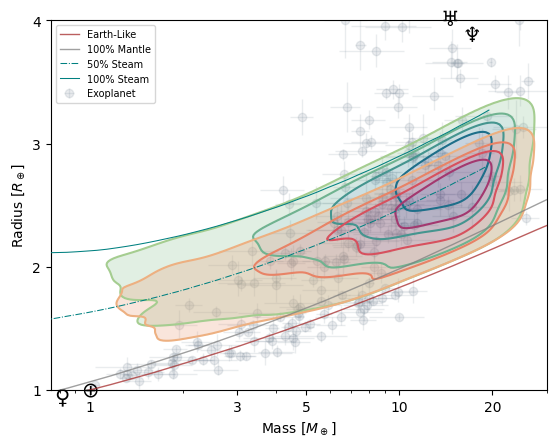

In [52]:
# plt.plot(x, rad_zeng(x,init_cmf_zeng),lw=2,color='brown',alpha=0.5,zorder=-10)

plt.plot(list_zeng_masses,list_zeng_ea_radii,linewidth=zeng_width,color='brown',alpha=0.75,zorder=6,label='Earth-Like')
plt.plot(list_zeng_masses,list_zeng_mg_radii,linewidth=zeng_width,color='grey',alpha=0.75,zorder=7,label='100% Mantle')

# plt.plot(zeng_mass,zeng_50wat,linewidth=zeng_width,color='darkturquoise',alpha=0.75,zorder=-8)
# plt.plot(zeng_mass,zeng_100wat,linewidth=zeng_width,color='darkturquoise',alpha=0.75,zorder=-9)
plt.plot(x, radius_m(x,init_wmf_swe,init_teq_swe,init_age_swe),lw=0.75,color='teal',linestyle='-.',zorder=19,label='50% Steam')
plt.plot(x, radius_g(x,init_wmf_swe100,init_teq_swe,init_age_swe),lw=0.75,color='teal',zorder=19,label='100% Steam')



# ADD SOLAR SYSTEM

# Data for masses and radii of planets (in Earth masses and Earth radii)
ss_planet_data = {
    # "Mercury": (0.055, 0.383),
    "Venus": (0.815, 0.949),
    "Earth": (1.0, 1.0),
    # "Mars": (0.107, 0.532),
    # "Jupiter": (317.8, 11.21),
    # "Saturn": (95.2, 9.45),
    "Uranus": (14.6, 4.01),
    "Neptune": (17.2, 3.88),
}

# Alchemy symbols for planets
ss_alchemy_symbols = {
    # "Mercury": "☿",
    "Venus": "♀",
    "Earth": "⊕",
    # "Mars": "♂",
    # "Jupiter": "♃",
    # "Saturn": "♄",
    "Uranus": "♅",
    "Neptune": "♆",
}

# Extracting data
ss_planets = list(ss_planet_data.keys())
ss_masses = [ss_planet_data[planet][0] for planet in ss_planets]
ss_radii = [ss_planet_data[planet][1] for planet in ss_planets]
ss_symbols = [ss_alchemy_symbols[planet] for planet in ss_planets]

for i in range(len(ss_planets)):
    text = plt.text(ss_masses[i], ss_radii[i], ss_alchemy_symbols[ss_planets[i]], \
            fontsize=15, ha='center', va='center', color='black')

# ------------------------------------------------ #
# KDE PLOT

i_color = sns.cm.crest
f_color = sns.cm.flare


# unicorn_killer = period_gp > 1

# # Plot KDE for Dataset 1
sns.kdeplot(x=mp_start/M_e, y=rp_start/R_e, cmap=i_color, log_scale=True, \
            label="Initial", levels=5)
sns.kdeplot(x=mp_start/M_e, y=rp_start/R_e, log_scale=True, fill=True, \
            cmap=i_color, levels=5, alpha=0.25, legend=True)

# Plot KDE for Dataset 2 #log_scale=True, 
sns.kdeplot(x=mp_end/M_e, y=rp_end/R_e, cmap=f_color, log_scale=True, \
            label="Final", levels=5)
sns.kdeplot(x=mp_end/M_e, y=rp_end/R_e, log_scale=True, fill=True, \
            cmap=f_color, levels=5, alpha=0.25,legend=True)


# Planets
list_exo_mpe = [abs(list_exo_mpe2), list_exo_mpe1]
list_exo_rpe = [abs(list_exo_rpe2), list_exo_rpe1]

# Exoplanets from the catalog file
catalog_points = plt.errorbar(list_exo_mp,list_exo_rp,
            yerr=list_exo_rpe,
            xerr=list_exo_mpe,
            fmt='o',zorder=-10,elinewidth=1,
            c="slategray",label='Exoplanet',alpha=0.15)  #slategrey
# plt.show()
# plt.axhline(1.8, color='black', linestyle='--', linewidth=.75) #1.8 R_e radius valley



# Add labels and title
plt.xlabel(r'Mass [$M_\oplus$]')
plt.ylabel(r'Radius [$R_\oplus$]')
plt.xscale('log')
plt.yscale('linear')
plt.xlim(0.75,30)
plt.ylim(1,4)
plt.xticks(ticks=[1,3,5,10,20],labels=['1','3','5','10','20'])
plt.yticks(ticks=[1,2,3,4],labels=['1','2','3','4'])
# plt.xlim(xmin, xmax)
# plt.ylim(ymin, ymax)
plt.legend(fontsize=7)

# import matplotlib.patches as mpatches
# handles = [mpatches.Patch(facecolor=sns.color_palette("crest", as_cmap=True), label="Initial"),
#            mpatches.Patch(facecolor=sns.color_palette("flare", as_cmap=True), label="Final")]  #sns.cm.crest(100)   sns.cm.flare(100)

plt.legend(loc="upper left", fontsize=7)

filename = f'{n_planets}_kde'
plt.savefig(f'./paper/plots/{filename}.png',dpi=600)
print(f'  File saved: {os.getcwd()}/{filename}.png')

# Show the plot
plt.show()


## IV. Sub-Neptune Desert KDE _(Fig 4)_

The SN Desert border comes from [A. Castro-Gonzalez's `nep-des`](https://github.com/castro-gzlz/nep-des).

In [7]:
H2O_init_rp_all = np.array([])
H2O_fin_rp_all = np.array([])
H2O_period_all = np.array([])

for i in range(n_planets):
    #H2O final values
    H2O_data = f'{filepath}/H2O/planet_{i+1}-{n_planets}_evolution_data.csv' #imported in Earth units
    H2O_rp_arr = np.loadtxt(H2O_data,usecols=(2),unpack=True) #,skiprows=1
    H2O_init_rp_all = np.append(H2O_init_rp_all, H2O_rp_arr[0])
    H2O_fin_rp_all = np.append(H2O_fin_rp_all, H2O_rp_arr[-1])

    H2O_period_all = np.append(H2O_period_all,period_gp[i])

In [8]:
nea_output_file = "Models/catalog_exoplanets_nea.dat"

#### Load in the latest data from the NASA Exoplanet Archive

In [11]:
NEA_TABLE = "ps"
base_dir = os.getcwd()
catalogue_data_dir = os.path.join(base_dir, "cat")
def _select_local_nea_file(table_name: str) -> str:
    """Return the newest local NEA CSV matching the requested table."""
    cat_dir = os.path.join(catalogue_data_dir, "NEA")
    if not os.path.isdir(cat_dir):
        raise FileNotFoundError(f"Directory not found: {cat_dir}")

    prefixes = {
        "ps": "PS_",
        "pscomppars": "PSCompPars_",
    }
    if table_name not in prefixes:
        raise ValueError("NEA_TABLE must be 'ps' or 'pscomppars'.")

    prefix = prefixes[table_name].lower()
    files = sorted(
        f for f in os.listdir(cat_dir)
        if f.lower().endswith(".csv") and f.lower().startswith(prefix)
    )
    if not files:
        raise FileNotFoundError(
            f"No local {table_name} CSV files found in {cat_dir}."
        )

    return os.path.join(cat_dir, files[-1])


def _load_local_nea_catalogue(table_name: str) -> pd.DataFrame:
    """Load a local NEA catalogue and keep one adopted solution per planet."""
    path = _select_local_nea_file(table_name)
    df = pd.read_csv(path, comment="#")

    if table_name == "ps":
        if "default_flag" not in df.columns:
            raise KeyError(
                "The selected ps file does not contain 'default_flag'."
            )
        df = df.loc[df["default_flag"] == 1].copy()

    if "pl_name" in df.columns:
        df = df.drop_duplicates(subset="pl_name", keep="first").copy()

    return df.reset_index(drop=True)


def load_catalog_PR(catalog, precision_radius=30.0, precision_mass=0.0):
    """
    Load a period–radius catalogue and apply basic quality cuts.
    """
    if catalog == "NEA":
        df = _load_local_nea_catalogue(NEA_TABLE)

    elif catalog == "Exoplanet.eu":
        cat_dir = os.path.join(catalogue_data_dir, "Exoplanet.eu")
        if not os.path.isdir(cat_dir):
            raise FileNotFoundError(f"Directory not found: {cat_dir}")

        files = sorted(f for f in os.listdir(cat_dir) if f.lower().endswith(".csv"))
        if not files:
            raise FileNotFoundError(f"No CSV files found in {cat_dir}.")
        df = pd.read_csv(os.path.join(cat_dir, files[-1]))

        rename_map = {
            "orbital_period": "pl_orbper",
            "radius": "pl_rade",
            "radius_error_min": "pl_radeerr2",
            "radius_error_max": "pl_radeerr1",
        }
        if "mass" in df.columns:
            rename_map["mass"] = "pl_bmasse"
        if "mass_error_min" in df.columns:
            rename_map["mass_error_min"] = "pl_bmasseerr2"
        if "mass_error_max" in df.columns:
            rename_map["mass_error_max"] = "pl_bmasseerr1"

        df = df.rename(columns=rename_map)

        if "pl_bmasse" in df.columns:
            mjup_to_mearth = 317.828
            df["pl_bmasse"] *= mjup_to_mearth
            if "pl_bmasseerr1" in df.columns:
                df["pl_bmasseerr1"] *= mjup_to_mearth
            if "pl_bmasseerr2" in df.columns:
                df["pl_bmasseerr2"] *= mjup_to_mearth

        if "pl_rade" in df.columns:
            rjup_to_rearth = 11.209
            df["pl_rade"] *= rjup_to_rearth
            if "pl_radeerr1" in df.columns:
                df["pl_radeerr1"] *= rjup_to_rearth
            if "pl_radeerr2" in df.columns:
                df["pl_radeerr2"] *= rjup_to_rearth

    else:
        raise ValueError("catalog must be 'NEA' or 'Exoplanet.eu'.")

    required_cols = {"pl_orbper", "pl_rade"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise KeyError(f"Missing required catalogue columns: {sorted(missing_cols)}")

    mask_phys = (
        np.isfinite(df["pl_orbper"].values)
        & np.isfinite(df["pl_rade"].values)
        & (df["pl_orbper"].values > 0.0)
        & (df["pl_rade"].values > 0.0)
    )
    df = df.loc[mask_phys].copy()

    if precision_mass > 0.0 and {"pl_bmasse", "pl_bmasseerr1", "pl_bmasseerr2"}.issubset(df.columns):
        M_pl = df["pl_bmasse"].values
        M_err = 0.5 * (
            np.abs(df["pl_bmasseerr1"].values)
            + np.abs(df["pl_bmasseerr2"].values)
        )
        mask_M = (
            np.isfinite(M_pl)
            & np.isfinite(M_err)
            & (M_pl > 0.0)
            & ((M_err / M_pl) < (precision_mass / 100.0))
        )
        df = df.loc[mask_M].copy()

    if precision_radius > 0.0 and {"pl_rade", "pl_radeerr1", "pl_radeerr2"}.issubset(df.columns):
        R_pl = df["pl_rade"].values
        R_err = 0.5 * (
            np.abs(df["pl_radeerr1"].values)
            + np.abs(df["pl_radeerr2"].values)
        )
        mask_R = (
            np.isfinite(R_pl)
            & np.isfinite(R_err)
            & (R_pl > 0.0)
            & ((R_err / R_pl) < (precision_radius / 100.0))
        )
        df = df.loc[mask_R].copy()

    P_catalog = df["pl_orbper"].to_numpy(float)
    R_catalog = df["pl_rade"].to_numpy(float)
    return df.reset_index(drop=True), P_catalog, R_catalog



df_cat, P_catalog, R_catalog = load_catalog_PR("NEA")

#### Make plot

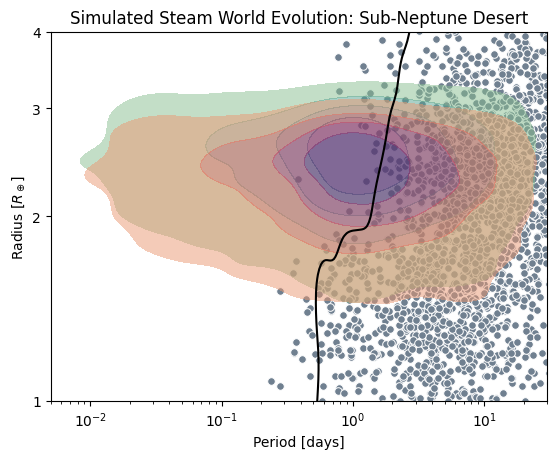

In [ ]:
#period-radius diagram
import requests
import os
from datetime import datetime
import argparse
import seaborn as sns
def check_internet_connection():
    """Check if there is internet access by pinging a known URL."""
    try:
        requests.get("https://www.google.com", timeout=5)
        return True
    except requests.ConnectionError:
        return False

def update_planets_exoplanet_catalog(catalog_url, output_file):
    """
    Updates the PlanetS exoplanet catalog from the DACE website.
    Warning: Work in progress, currently not working
    """
    if True:
        print("PlanetS auto update currently not implemented, skipping updating attempt.")
        return

    if not check_internet_connection():
        print("No internet connection. Unable to update the exoplanet catalog.")
        return

    try:
        response = requests.get(catalog_url, timeout=10)
        response.raise_for_status()  # Raise an error for HTTP issues
        
        # Prepare the header
        header = [
            "# NASA Exoplanet Catalog",
            f"# Source: {catalog_url}",
            f"# Catalog last updated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        ]
        
        # Write the header and data to the file
        with open(output_file, "w") as f:
            f.write("\n".join(header) + "\n")
            # Add '#' to the parameter names
            data_lines = response.text.splitlines()
            f.write("# " + data_lines[0] + "\n")  # Add # to parameter names
            f.write("\n".join(data_lines[1:]) + "\n")
        
        print(f"Catalog updated successfully and saved to {output_file}")
    except requests.RequestException as e:
        print(f"Error fetching the catalog: {e}")

def read_planets_last_update(output_file):
    """
    Reads the date of the last update from the catalog file and prints it.
    Parameters:
        output_file (str): Path to the catalog file.
    """
    if not os.path.exists(output_file):
        print("Catalog file does not exist.")
        return

    try:
        with open(output_file, "r") as f:
            for line in f:
                text_lookup = "# Catalog last updated:"
                if line.startswith(text_lookup):
                    print("# PlanetS catalog last updated: ",line.replace(text_lookup,'').replace('\n',''))
                    break
    except Exception as e:
        print(f"Error reading the catalog: {e}")


plt.scatter(P_catalog,R_catalog,
        ec="white",
        fc="slategrey",
        s=30,
        lw=0.7,
        alpha=1.0,
        zorder=1,
    )

i_color = sns.cm.crest
f_color = sns.cm.flare

sns.kdeplot(x=H2O_period_all,y=H2O_init_rp_all/R_e, 
            log_scale=True, levels=5,
            cmap=i_color, fill=True, alpha=0.5, label="Initial State", legend=True)
sns.kdeplot(x=H2O_period_all,y=H2O_fin_rp_all/R_e,
            log_scale=True,levels=5,
            cmap=f_color, fill=True, alpha=0.5, label="Final State", legend=True)

des_file = "Models/desert_boundaries.txt"
des_x, des_y, = np.loadtxt(des_file,usecols=(0,1), skiprows=1, unpack=True)

plt.plot(10**des_x, 10**des_y,color='black',label="Sub-Neptune Desert")
plt.title("Simulated Steam World Evolution: Sub-Neptune Desert")
plt.xscale("log")
plt.xlim(0.005,30)
plt.xlabel("Period [days]")
plt.ylabel(r"Radius [$R_\oplus$]")
plt.yticks([1,2,3,4], labels=[1,2,3,4])
plt.ylim(1,4)
plt.legend(fontsize=7)
plt.savefig(savepath+'/sn_desert_'+identifier+'.png', pad_inches=0.2, dpi=600)